In [1]:
!pip install window_ops
!pip install statsforecast
!pip install mlforecast
!pip install lightgbm


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 30.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

from mlforecast import MLForecast
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

from mlforecast.target_transforms import Differences
from window_ops.rolling import rolling_mean

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape, bias

In [4]:
df = pd.read_parquet('/work/sample_hotels-1.parquet')

df['ds'] = pd.to_datetime(df['ds'])

otb_cols = [f'otb_{i}' for i in range(28, 61) if f'otb_{i}' in df.columns]

df = df[['unique_id', 'ds', 'y', 'location_type', 'hotel_type'] + otb_cols]

df = df.query("unique_id not in ['hotel_77', 'hotel_28']")

In [41]:
#  the training/test set first
train_df = df.groupby('unique_id').head(-28).reset_index(drop=True)
test_df = df.groupby('unique_id').tail(28).reset_index(drop=True)

#  dummy variables for categorical predictors 
train_df_dummies = df.groupby('unique_id').apply(lambda x: x.iloc[:-28]).reset_index(drop=True)

# Identify the names of these new dummy columns for later use 
dummies = [c for c in train_df_dummies if 'location_type_' in c or 'hotel_type_' in c]

In [8]:
ml_models = {
    'LGBM': LGBMRegressor(random_state=42, verbosity=-1),
    'RF': RandomForestRegressor(random_state=42)
}

In [10]:
ml = MLForecast(
    models=ml_models,
    freq='D',
    lags=[28, 29, 35], 
    lag_transforms={
        28: [(rolling_mean, 7)]
    },
    target_transforms=[Differences([7])]
    

)

In [12]:
key_predictors = ['otb_28'] + dummies

cv_ml = ml.cross_validation(
    df=train_df_dummies[['unique_id', 'ds', 'y'] + key_predictors],
    h=28,
    n_windows=5,
    step_size=28,
    static_features=[]  # dummies are static, otb_28 is dynamic
)

In [29]:
#without mape
eval_ml = evaluate(
    df = cv_ml,
    metrics = [mae, rmse, bias],
    models=['RF', 'LGBM']
)
eval_ml = eval_ml.drop(columns=['cutoff']).groupby(['unique_id','metric']).mean().reset_index()
eval_ml

,unique_id,metric,RF,LGBM
0,hotel_0,bias,0.061539,0.052970
1,hotel_0,mae,0.207052,0.206011
2,hotel_0,rmse,0.246480,0.247536
3,hotel_105,bias,-0.076989,-0.083798
4,hotel_105,mae,0.145146,0.150690
5,hotel_105,rmse,0.180425,0.188291
6,hotel_112,bias,-0.063434,-0.056177
7,hotel_112,mae,0.130839,0.132579
8,hotel_112,rmse,0.157052,0.159616
9,hotel_126,bias,0.045586,0.052239


In [31]:
#with mape
eval_ml = evaluate(
    df = cv_ml,
    metrics = [mae, rmse,mape, bias],
    models=['RF', 'LGBM']
)
eval_ml = eval_ml.drop(columns=['cutoff']).groupby(['unique_id','metric']).mean().reset_index()
eval_ml

,unique_id,metric,RF,LGBM
0,hotel_0,bias,0.061539,0.052970
1,hotel_0,mae,0.207052,0.206011
2,hotel_0,mape,0.328092,0.327884
3,hotel_0,rmse,0.246480,0.247536
4,hotel_105,bias,-0.076989,-0.083798
...,...,...,...,...
63,hotel_91,rmse,0.237148,0.235396
64,hotel_98,bias,-0.036793,-0.036555
65,hotel_98,mae,0.158670,0.156084
66,hotel_98,mape,0.779798,0.752020


MAPE was included for all series but should be interpreted cautiously for hotel\_7, hotel\_35, hotel\_42, and hotel\_98, which showed consistently high MAPE values across all models\. This likely reflects periods of near\-zero occupancy in these hotels, which inflates MAPE since it is divided by the actual value\. For these series we rely more heavily on MAE and RMSE as the primary accuracy metrics

In [15]:
eval_ml['best_model'] = eval_ml[['RF', 'LGBM']].idxmin(axis=1)

In [17]:
win_counts = (
    eval_ml
    .groupby(['metric', 'best_model'])
    .size()
    .reset_index(name='wins')
)

display(win_counts)

,metric,best_model,wins
0,bias,LGBM,7
1,bias,RF,10
2,mae,LGBM,12
3,mae,RF,5
4,mape,LGBM,11
5,mape,RF,6
6,rmse,LGBM,11
7,rmse,RF,6


In [19]:
ml_models = ['RF', 'LGBM']

In [21]:
metrics = ['mae', 'rmse', 'mape', 'bias']
summary_list = []

for m in metrics:
    wins = (
        eval_ml.query(f"metric == '{m}'")
        .assign(winner = lambda x: x[ml_models].idxmin(axis=1))
        ['winner'].value_counts()
    )
    summary_list.append(wins.rename(m.upper()))

# Merge into one summary DataFrame
win_summary_table = pd.concat(summary_list, axis=1).fillna(0).astype(int)
display(win_summary_table)

,MAE,RMSE,MAPE,BIAS
winner,,,,
LGBM,12,11,11,7
RF,5,6,6,10


In [35]:
test_df_with_pred = (
    df.groupby('unique_id')
    .tail(28)
    .reset_index(drop=True)
)
test_df_with_pred = pd.get_dummies(test_df_with_pred, columns=['location_type', 'hotel_type'], dtype=float)

In [43]:
ml.fit(
    train_df_dummies[['unique_id', 'ds', 'y'] + key_predictors],
    static_features=dummies
)

forecast_ml = ml.predict(
    h=28,
    X_df=test_df_with_pred[['unique_id', 'ds'] + key_predictors]
)

results_test_ml = forecast_ml.merge(
    test_df[['unique_id', 'ds', 'y']],
    on=['unique_id', 'ds']
)

eval_test_ml = evaluate(
    df=results_test_ml,
    metrics=[bias, mae, rmse, mape],
    models=['LGBM', 'RF']
)
display(eval_test_ml)

,unique_id,metric,LGBM,RF
0,hotel_0,bias,-0.163256,-0.212153
1,hotel_105,bias,0.061084,0.070794
2,hotel_112,bias,-0.000619,-0.002468
3,hotel_126,bias,-0.007907,-0.006253
4,hotel_133,bias,0.086241,0.076257
...,...,...,...,...
63,hotel_7,mape,0.406776,0.341888
64,hotel_70,mape,0.286253,0.280905
65,hotel_84,mape,0.123679,0.111132
66,hotel_91,mape,0.157053,0.163519


In [45]:
eval_test_ml.to_csv('mlforecast_test_eval.csv', index=False)
results_test_ml.to_csv('mlforecast_test_forecasts.csv', index=False)


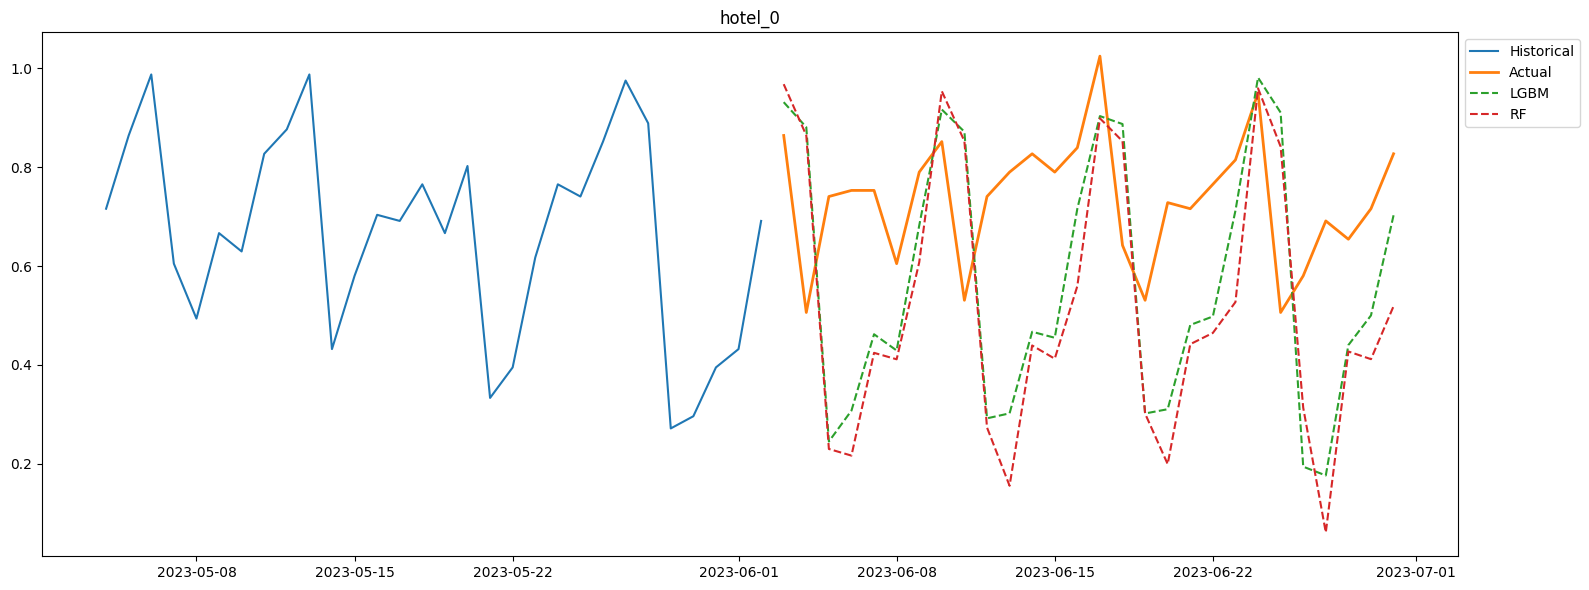

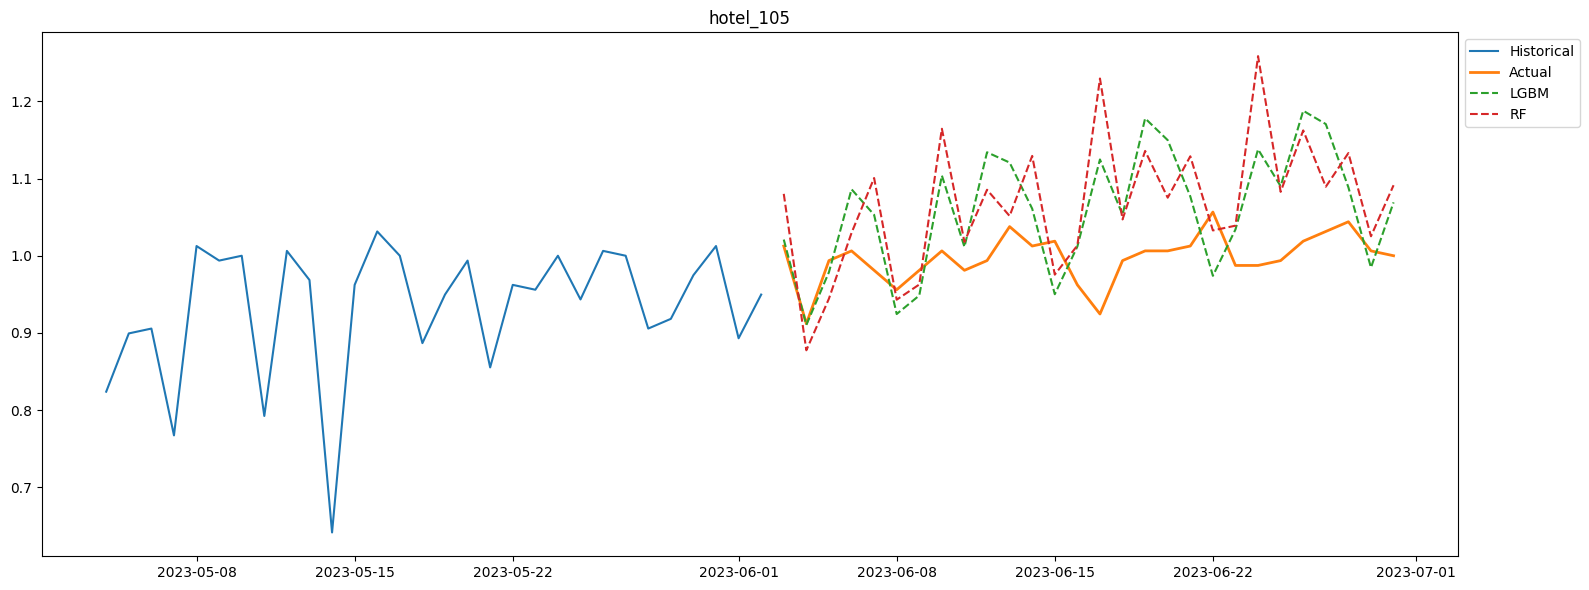

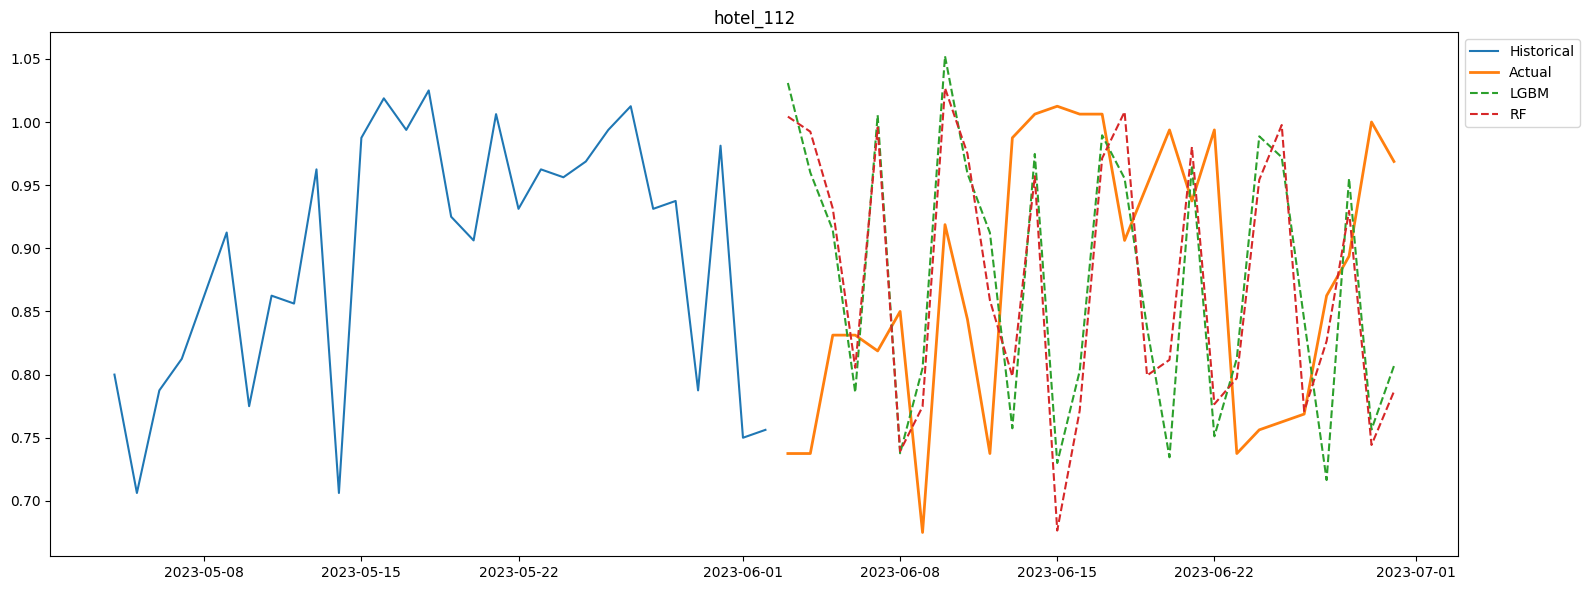

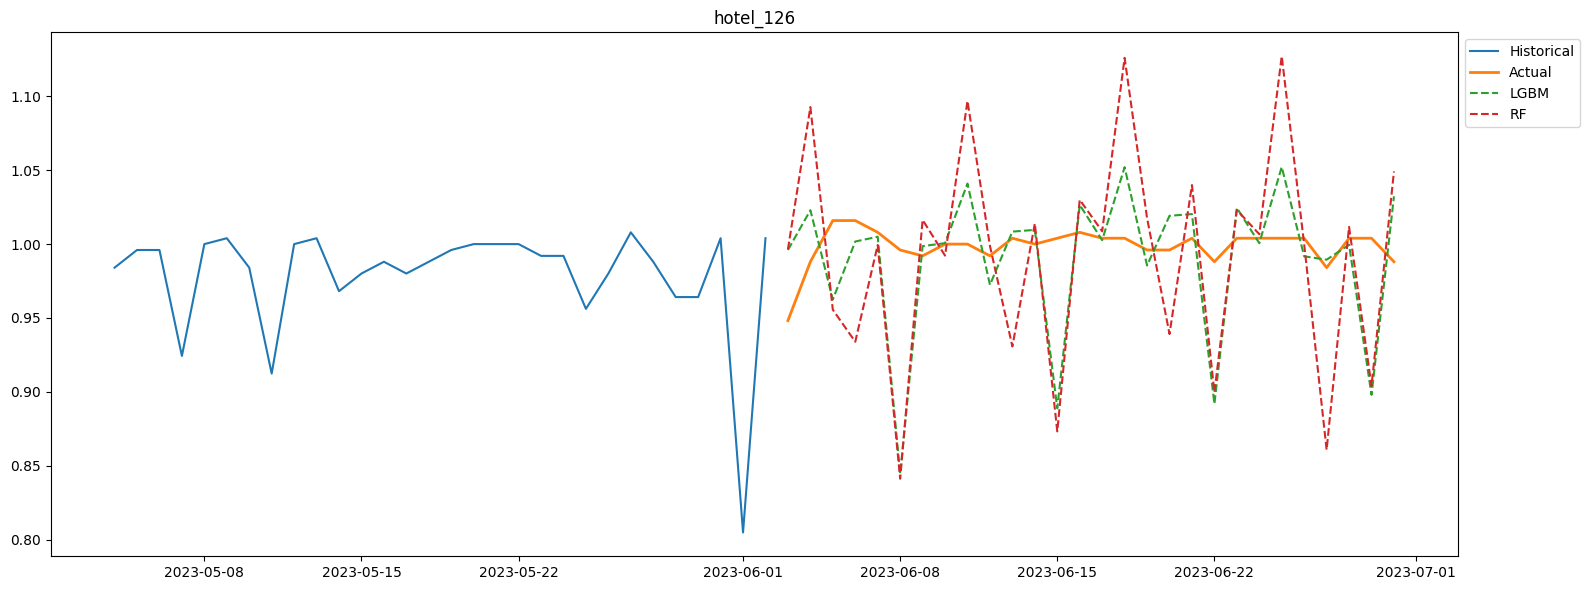

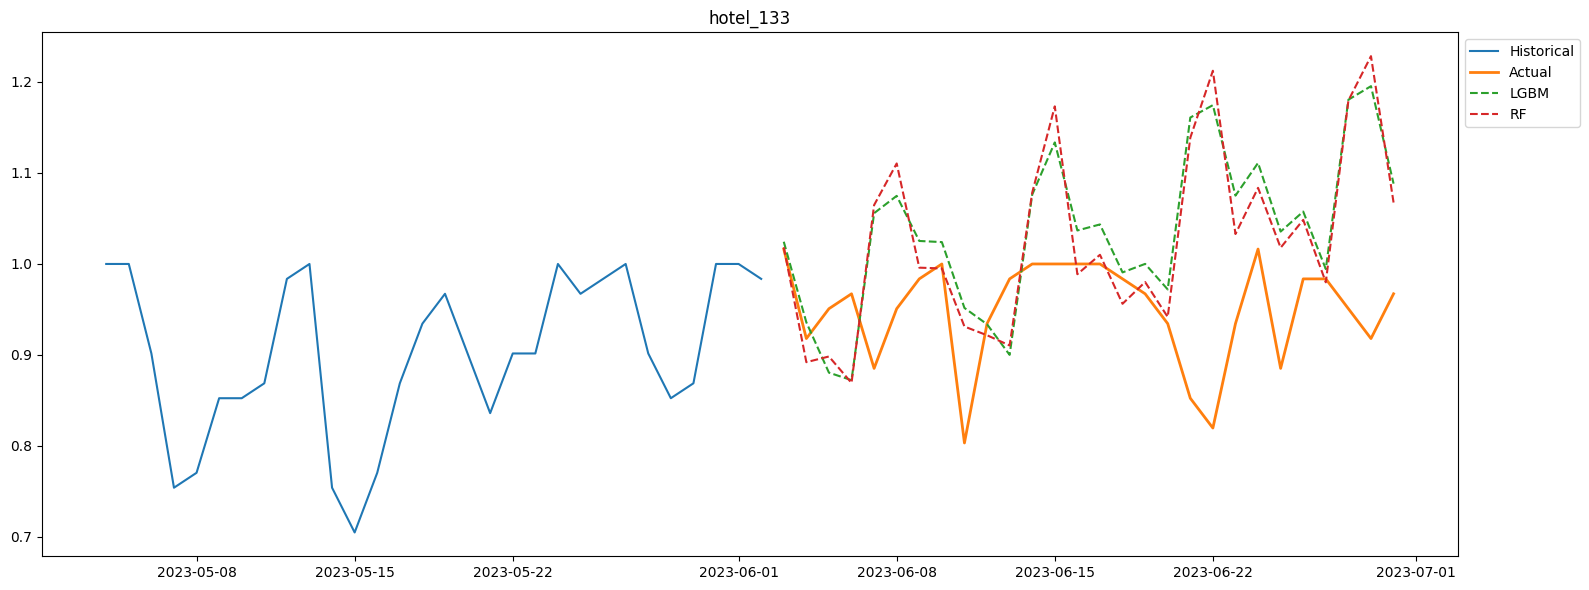

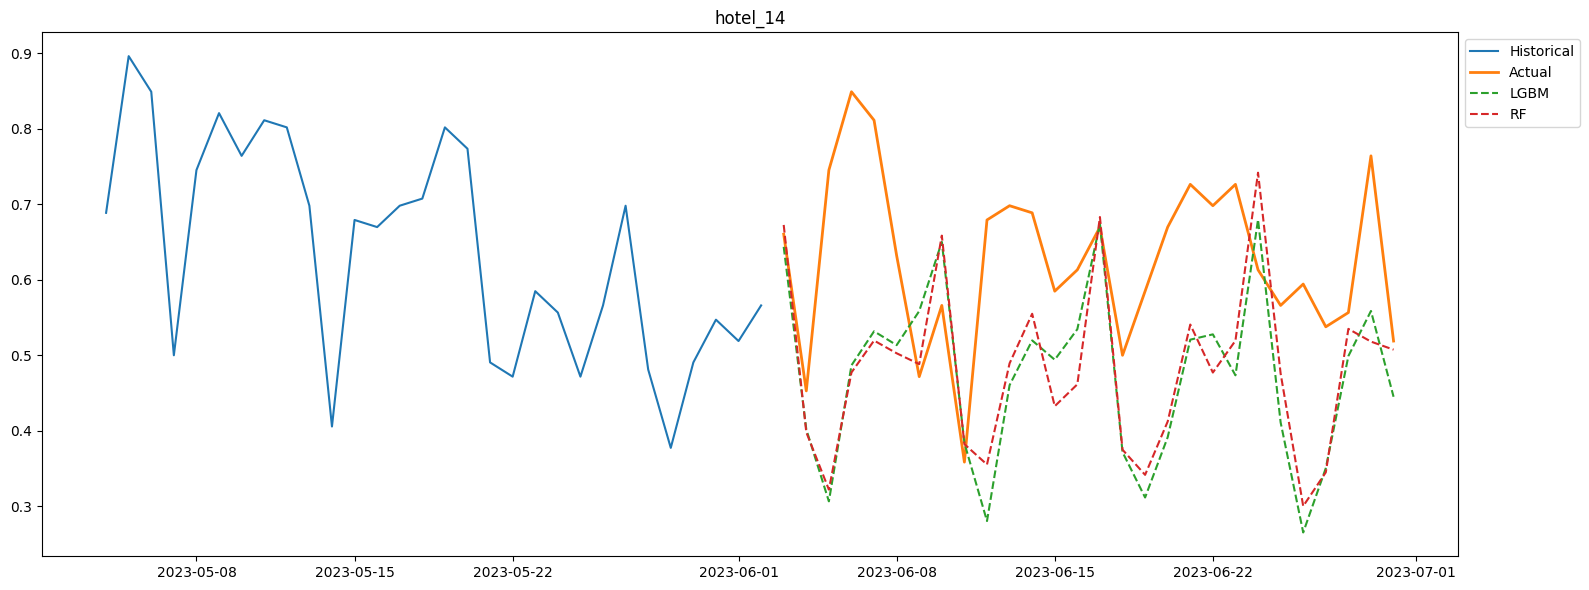

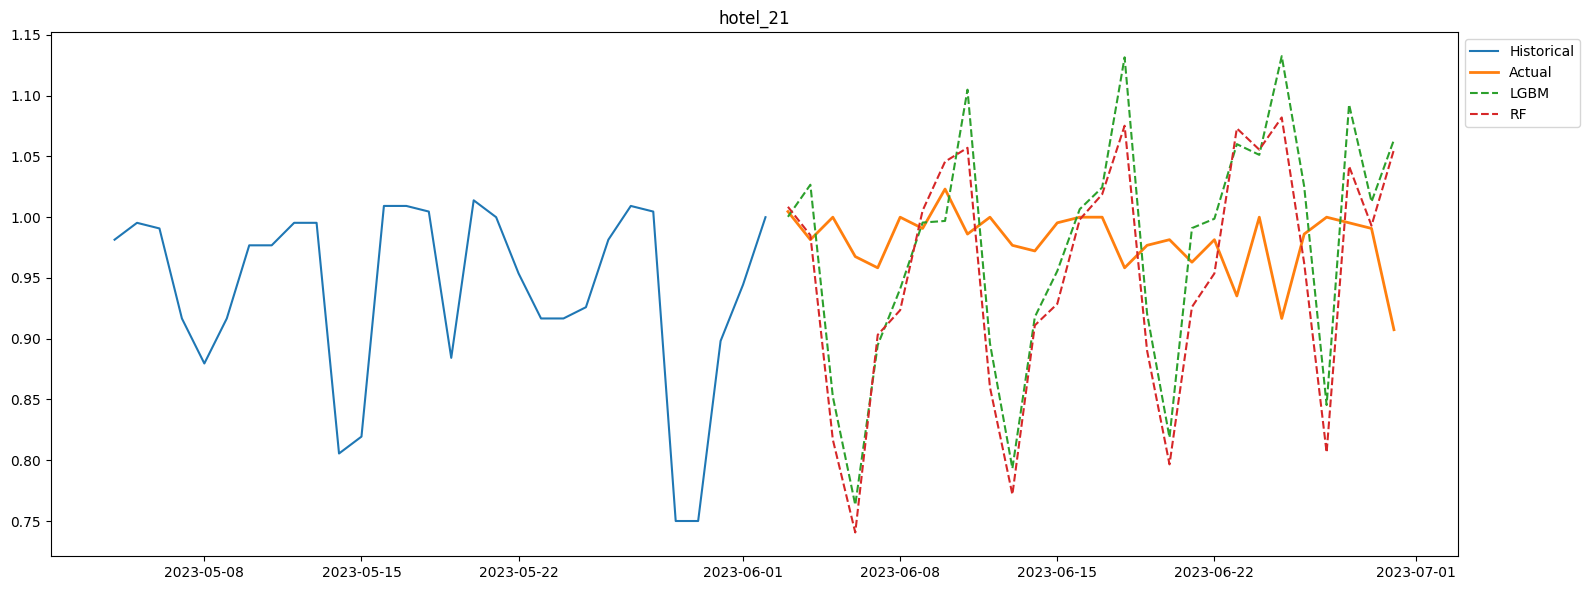

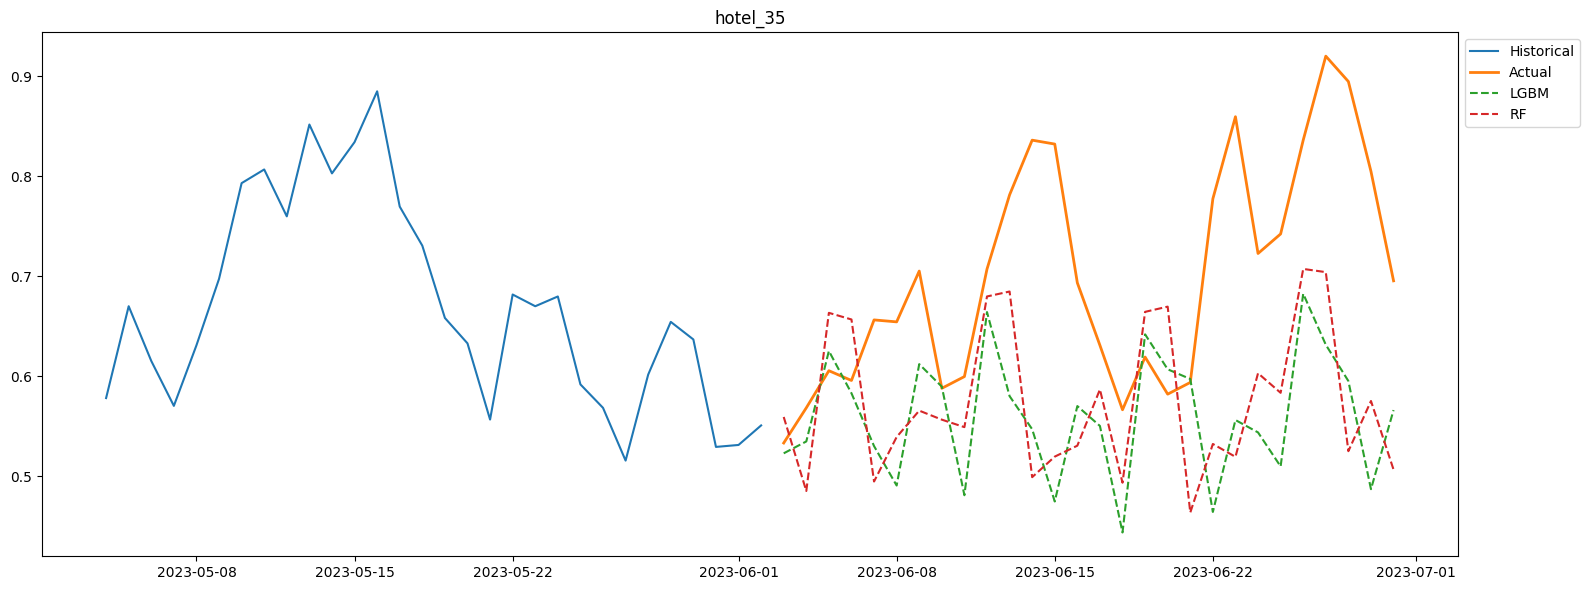

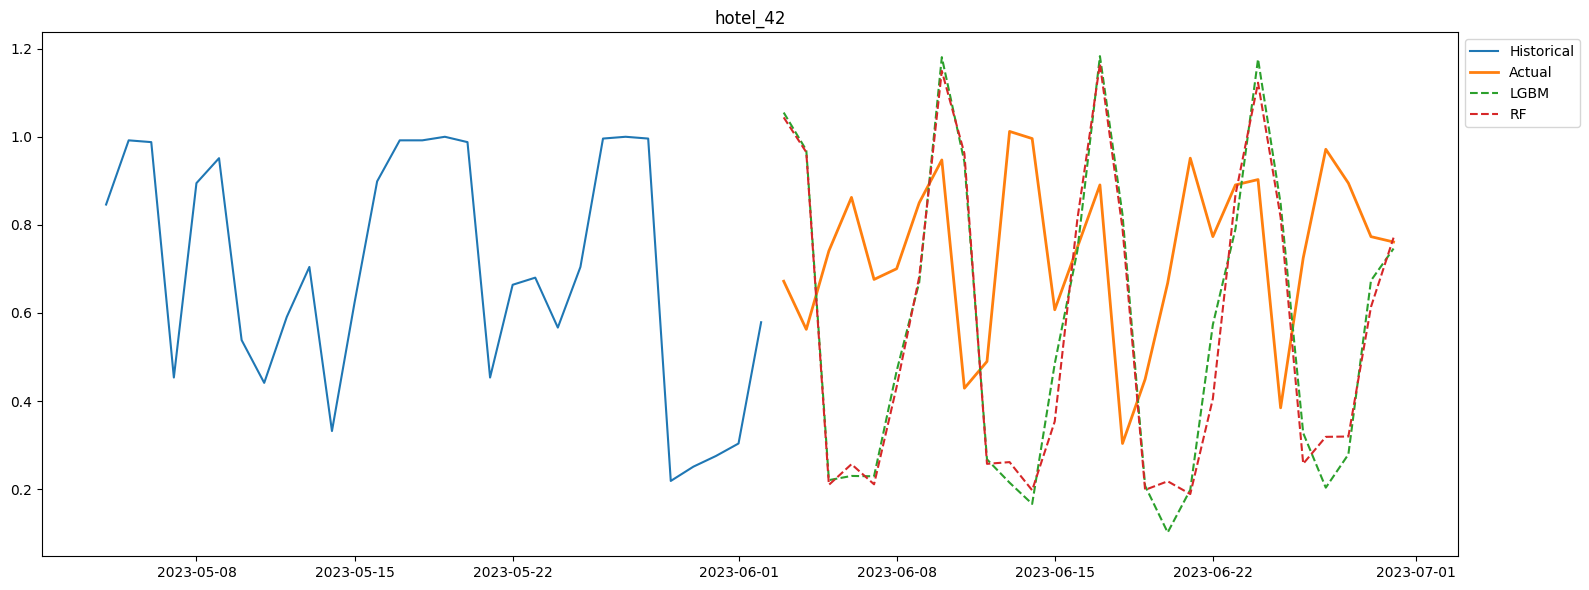

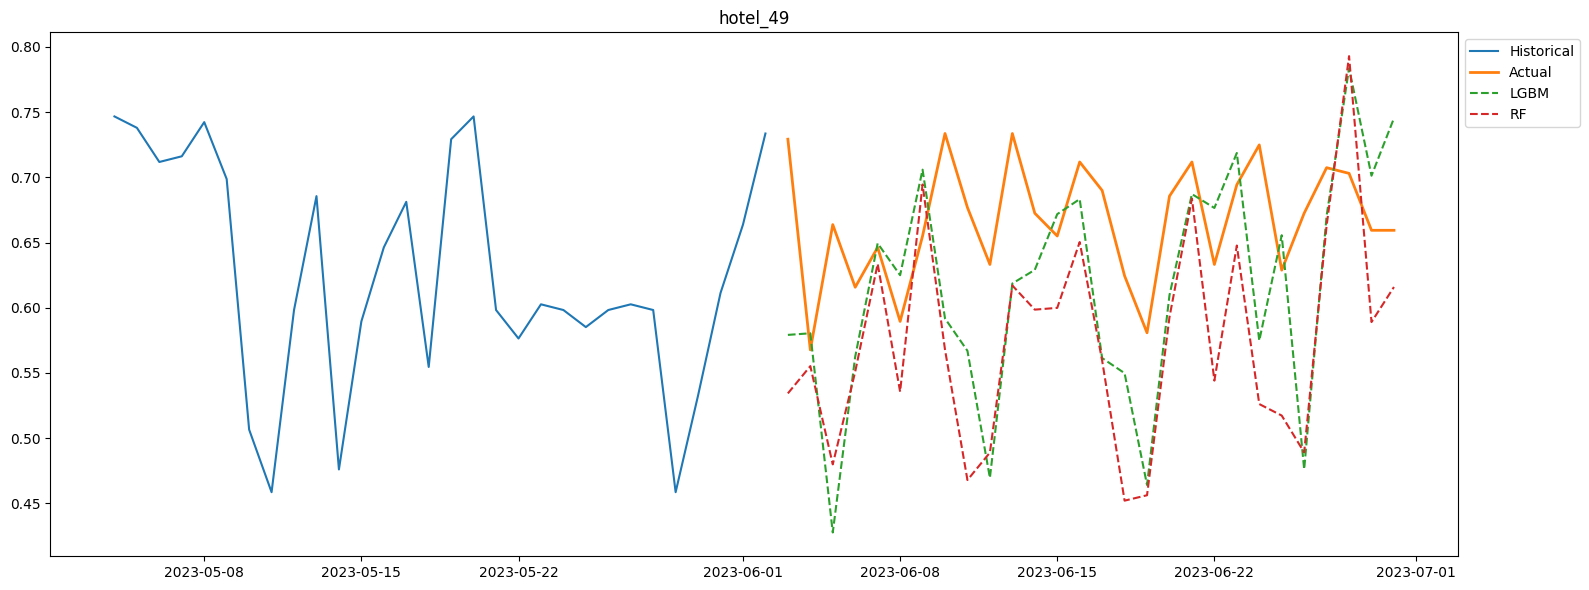

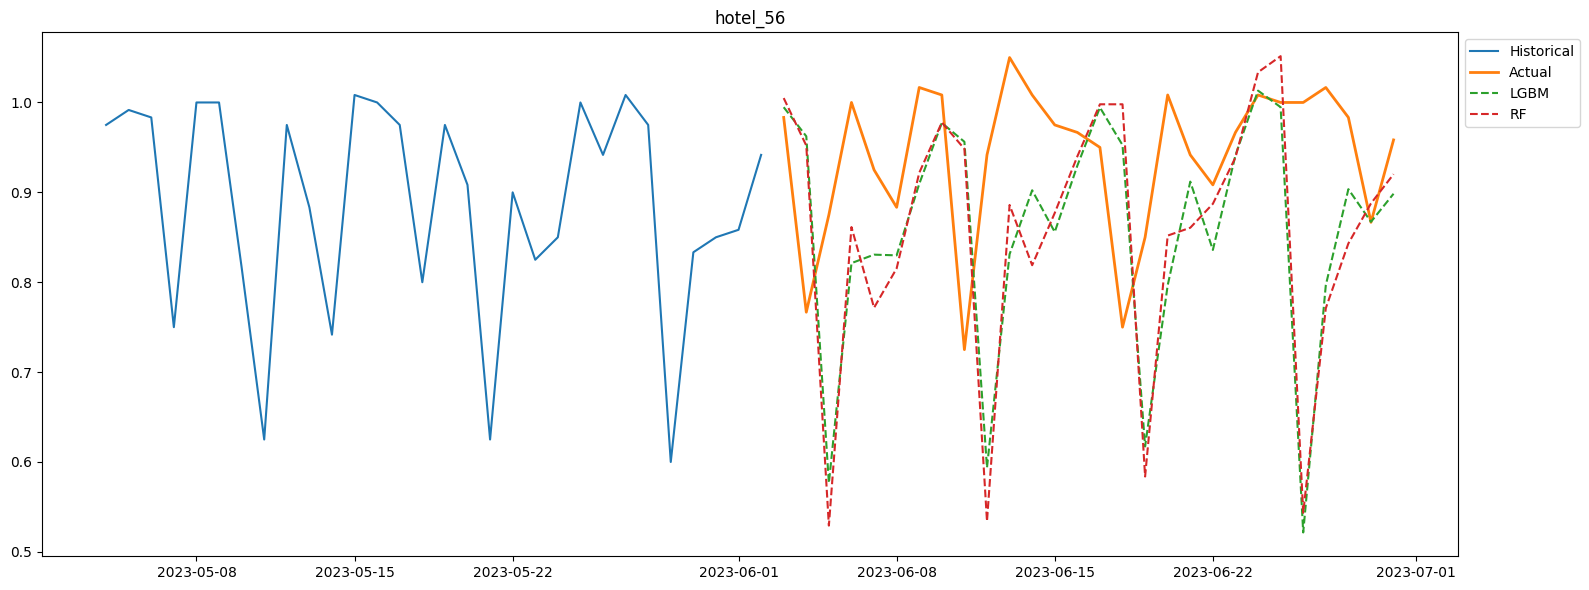

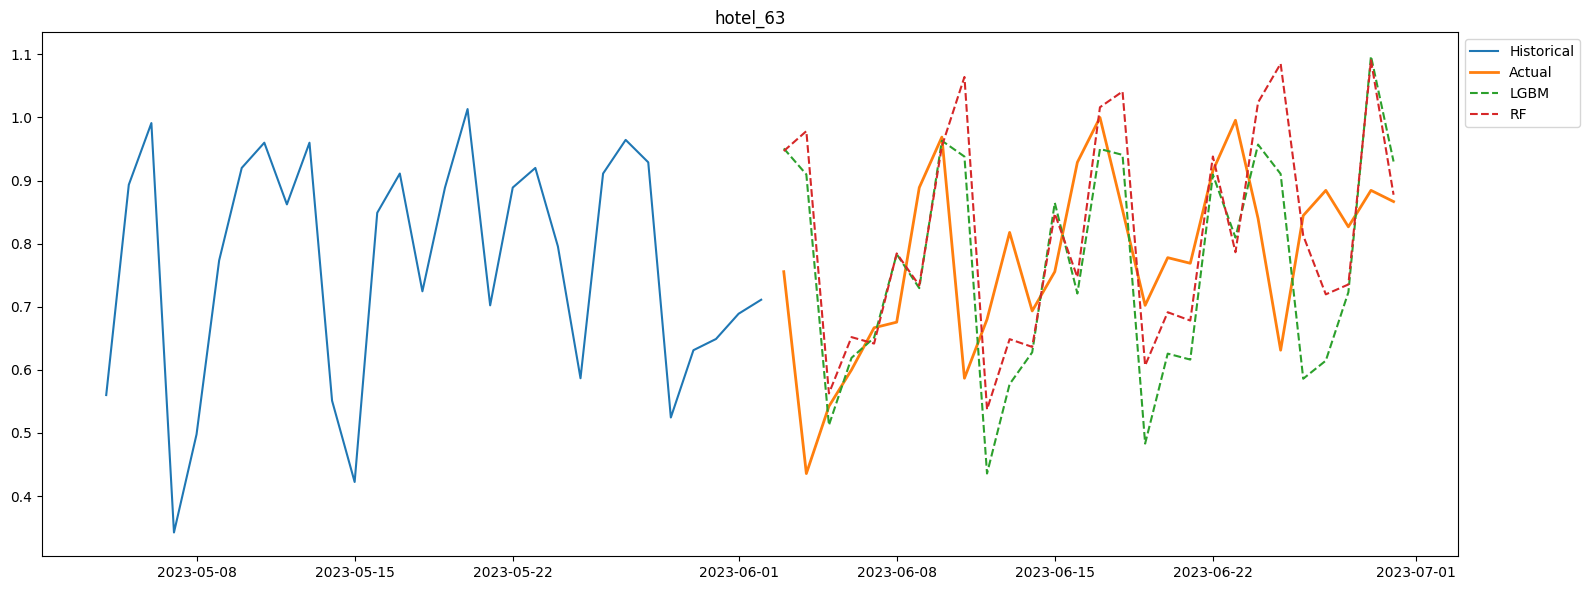

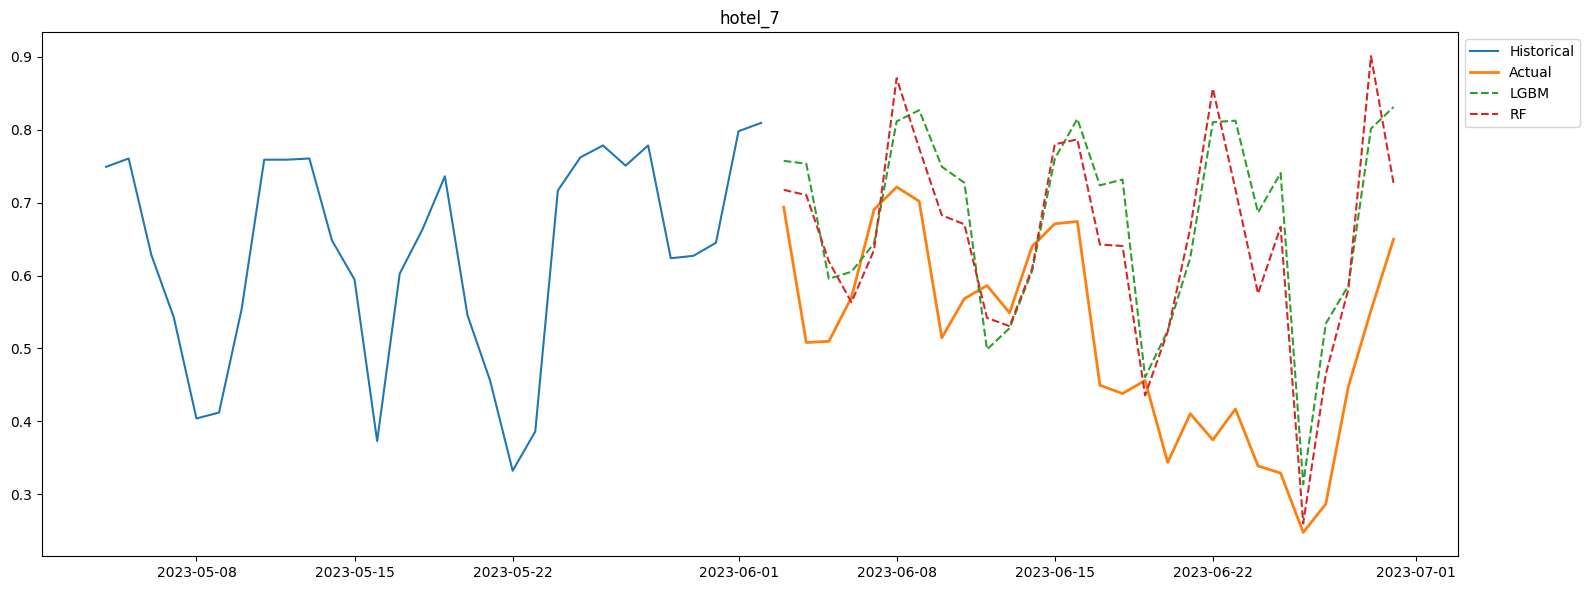

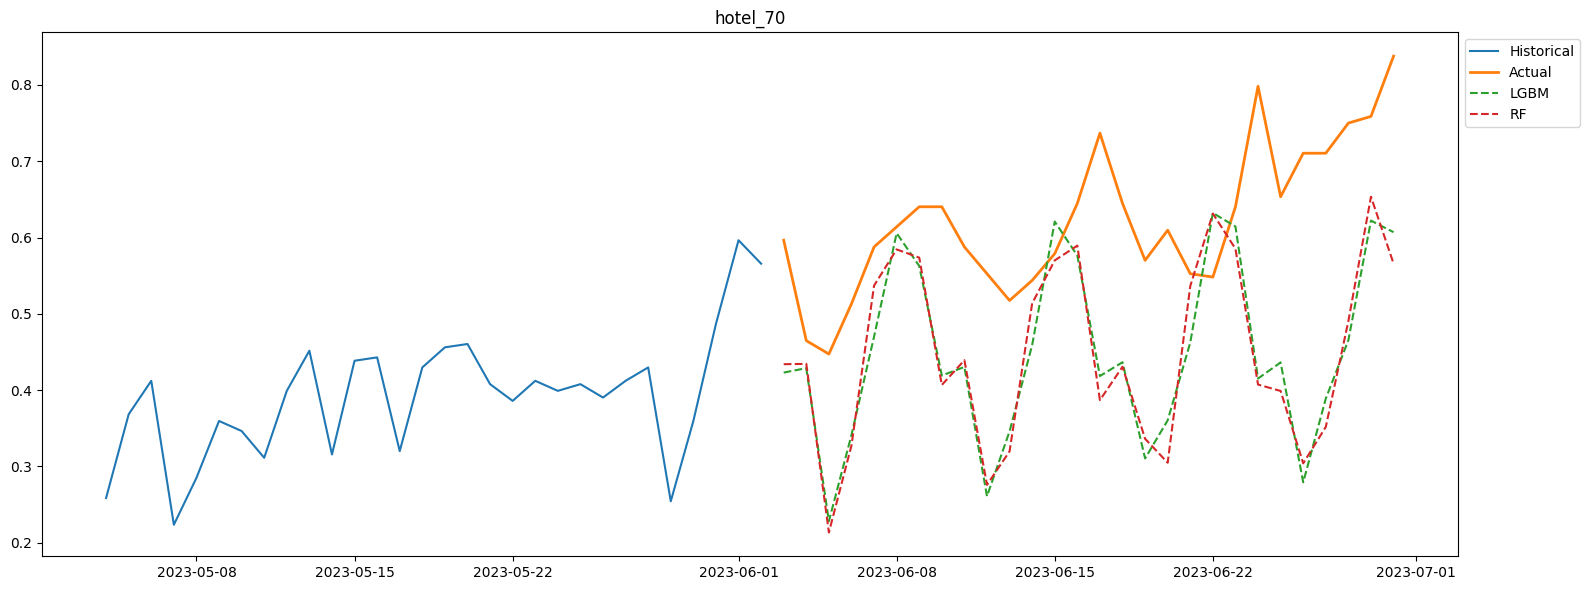

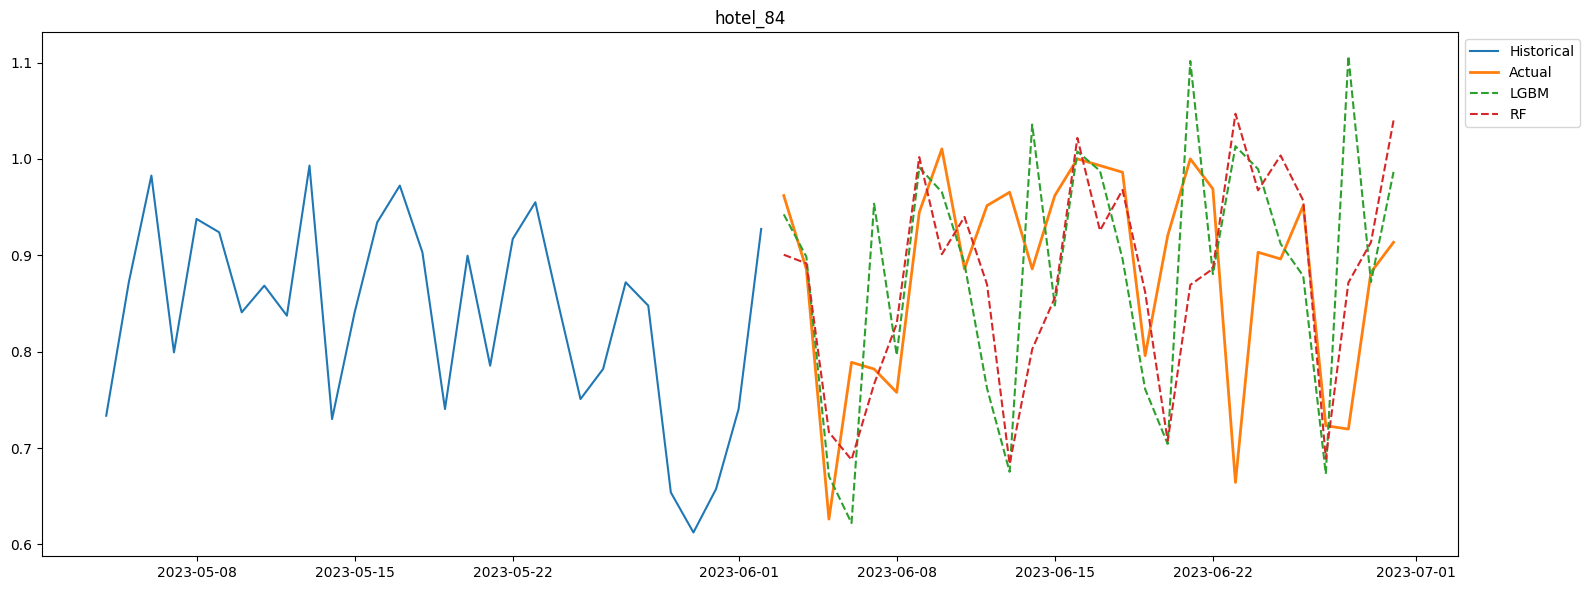

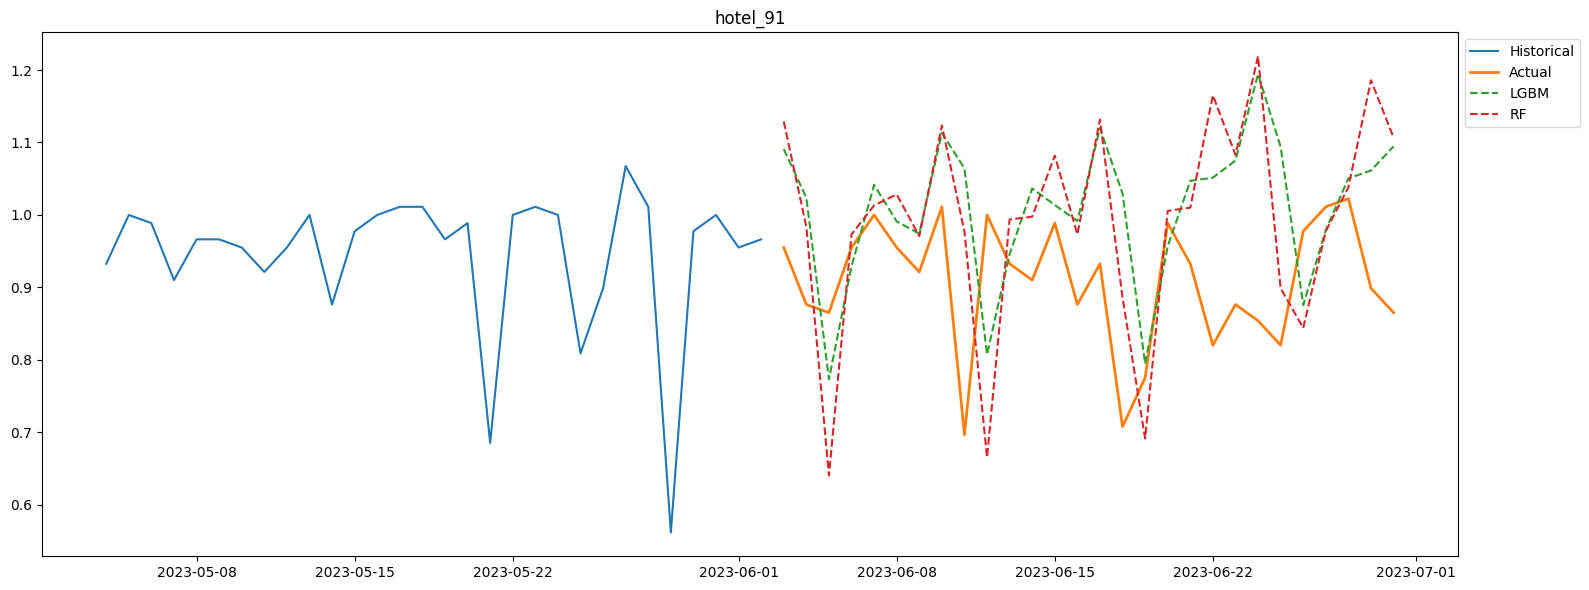

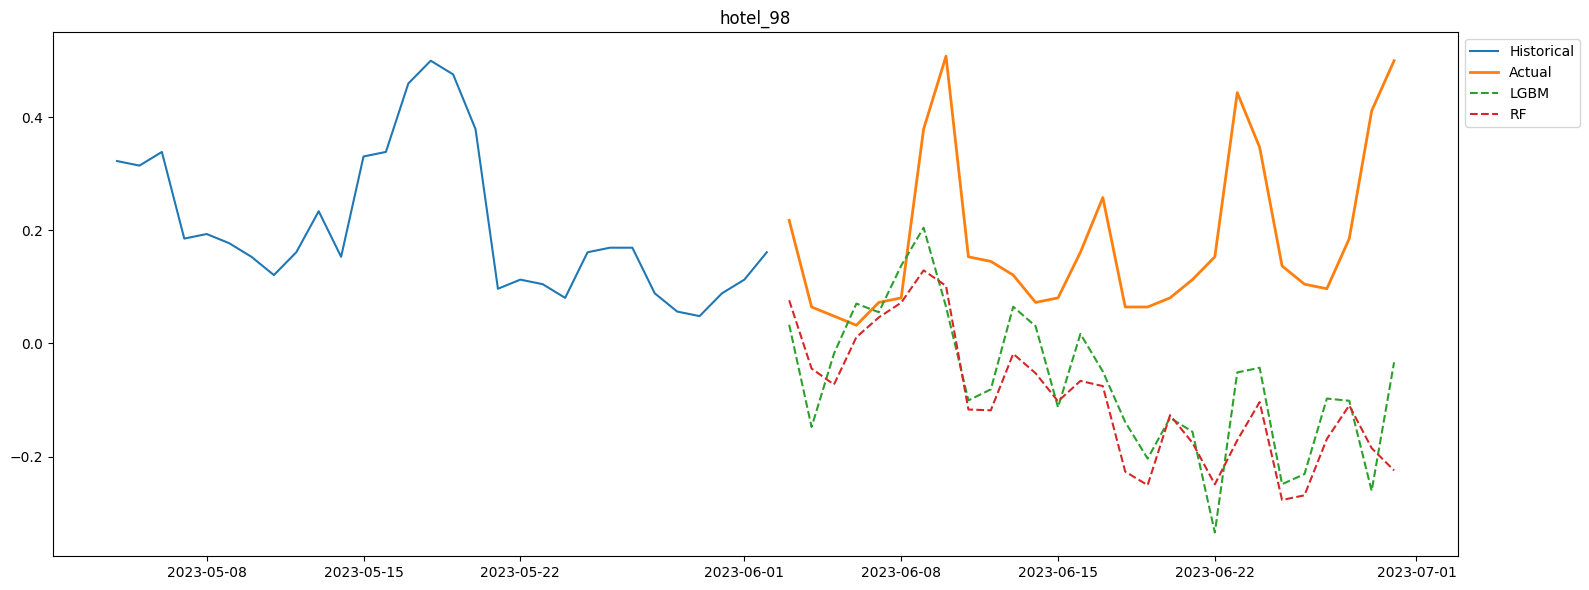

In [47]:
import matplotlib.pyplot as plt

for hotel_id in results_test_ml['unique_id'].unique():
    actual  = test_df[test_df['unique_id'] == hotel_id]
    preds   = results_test_ml[results_test_ml['unique_id'] == hotel_id]
    history = train_df[train_df['unique_id'] == hotel_id].tail(30)

    plt.figure(figsize=(16, 6))
    plt.plot(history['ds'], history['y'], label='Historical')
    plt.plot(actual['ds'], actual['y'], label='Actual', linewidth=2)
    plt.plot(preds['ds'], preds['LGBM'], label='LGBM', linestyle='--')
    plt.plot(preds['ds'], preds['RF'], label='RF', linestyle='--')
    plt.title(hotel_id)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

### TabPFN

In [52]:
#!pip install tabpfn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [56]:
from tabpfn import TabPFNRegressor
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences

# 1. Initialize with specific arguments to avoid the "missing arguments" error
# TabPFN often expects a 'device' and 'n_estimators' or similar depending on version
tpfn_model = TabPFNRegressor(device='cpu') 

# 2. Put it in your MLForecast object
fcst = MLForecast(
    models={
        'lgbm': LGBMRegressor(verbosity=-1),
        'tabpfn': tpfn_model  # Give it a string name in a dictionary
    },
    freq='D',
    lags=[1, 7, 14],
    date_features=['dayofweek', 'month']
)

In [78]:
# Convert object columns to categories so LightGBM can process them
train_df['location_type'] = train_df['location_type'].astype('category')
train_df['hotel_type'] = train_df['hotel_type'].astype('category')

# Now run your CV
cv_results = fcst.cross_validation(
    df=train_df,
    h=28,
    step_size=28,
    n_windows=5,
    static_features=['location_type', 'hotel_type'] # Include them here now that they are categories
)

TabPFNLicenseError: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"

In [ ]:
evaluation_df = evaluate(
    cv_results,
    metrics=[mae, rmse],
    id_col='unique_id',
    target_col='y'
)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=94252149-99d5-4a3a-8951-54d7f526c43a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>